
# Métodos Estadísticos — Métricas Avanzadas

## Universidad de Navarra · Programa PwC · 2026

**Objetivo del notebook:** entender las métricas más importantes que utilizaremos para interpretar cuatro modelos de `scikit-learn`:

1. **PCA** — reducción de dimensionalidad / análisis factorial sencillo
2. **K-Means** — clustering
3. **Linear Regression** — regresión lineal
4. **Logistic Regression** — clasificación binaria

La clase se centra en **qué mide cada métrica, cómo se calcula, cómo se visualiza y cómo debemos interpretarla**. No buscamos todavía profundizar en todas las variantes de cada método.

> **Idea central:** un modelo no termina cuando obtenemos una predicción. Tenemos que saber **qué información explica**, **qué error comete** y **cómo medir su calidad**.



## Flujo conceptual

```text
DATOS
  ↓
MODELO
  ↓
PREDICCIONES / COMPONENTES / CLUSTERS
  ↓
MÉTRICAS
  ↓
INTERPRETACIÓN
```

En este notebook utilizaremos datos de práctica de GitHub. Las fuentes se mantienen explícitas para que el material sea reproducible.


In [1]:

# ==============================================
# Configuración común
# ==============================================
import warnings
warnings.filterwarnings('ignore')

import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from urllib.request import urlopen, Request
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_squared_error, r2_score,
    confusion_matrix, accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve, classification_report
)

plt.rcParams['figure.figsize'] = (9, 5)
plt.rcParams['axes.grid'] = True


def cargar_desde_url(url, tipo='csv'):
    """Carga un CSV o Excel desde una URL."""
    if tipo == 'csv':
        return pd.read_csv(url)
    if tipo == 'excel':
        return pd.read_excel(url)
    raise ValueError("tipo debe ser 'csv' o 'excel'")


def columnas_numericas_utiles(df):
    """Selecciona columnas numéricas y excluye identificadores evidentes por nombre."""
    num = df.select_dtypes(include=np.number).copy()
    id_tokens = ('id', 'index', 'indice', 'codigo', 'code', 'serial')
    drop = []
    for c in num.columns:
        name = str(c).strip().lower().replace('-', '_').replace(' ', '_')
        if name in {'id', 'index', 'indice'} or any(tok in name for tok in id_tokens):
            drop.append(c)
    usable = [c for c in num.columns if c not in drop]
    return num[usable] if usable else num


# 1. PCA — Principal Component Analysis

### Dataset: `crime.csv`

PCA transforma un conjunto de variables correlacionadas en componentes principales ordenados por la cantidad de **varianza** que explican.

En esta clase no entraremos en la derivación matemática de los eigenvectors; nos centraremos en dos preguntas prácticas:

- ¿Cuánta información explica cada componente?
- ¿Cuánta información acumulada explican los primeros componentes?

### Métrica 1 — Scree Plot

El **Scree Plot** muestra la varianza explicada por cada componente.

Si:

$$
\lambda_j = \text{varianza explicada por el componente } j
$$

entonces, utilizando los datos estandarizados:

$$
\text{Explained Variance Ratio}_j = \frac{\lambda_j}{\sum_{k=1}^{p} \lambda_k}
$$

La idea visual es buscar dónde empiezan a aparecer ganancias cada vez menores.

### Métrica 2 — Total Variance Explained

La varianza acumulada hasta el componente `m` es:

$$
TVE(m)=\sum_{j=1}^{m} EVR_j
$$

Por ejemplo, si los dos primeros componentes explican 0,72, entonces explican conjuntamente el **72 % de la varianza total**.


In [2]:

CRIME_URL = 'https://github.com/manoelgadi/PSDMA/raw/refs/heads/main/datasets/crime.csv'
crime = cargar_desde_url(CRIME_URL, 'csv')
crime.head()


,STATE,MURDER,RAPE,ROBBERY,ASSAULT,BURGLARY,LARCENY,AUTO
0,ALABAMA,14.2,25.2,96.8,278.3,1135.5,1881.9,280.7
1,ALASKA,10.8,51.6,96.8,284.0,1331.7,3369.8,753.3
2,ARIZONA,9.5,34.2,138.2,312.3,2346.1,4467.4,439.5
3,ARKANSAS,8.8,27.6,83.2,203.4,972.6,1862.1,183.4
4,CALIFORNIA,11.5,49.4,287.0,358.0,2139.4,3499.8,663.5


In [3]:

# Seleccionamos variables numéricas y rellenamos faltantes con la mediana
X_crime = columnas_numericas_utiles(crime)
X_crime = X_crime.fillna(X_crime.median(numeric_only=True))

scaler = StandardScaler()
X_crime_scaled = scaler.fit_transform(X_crime)

pca = PCA()
X_pca = pca.fit_transform(X_crime_scaled)

# Variables después de la transformación PCA: los componentes principales.
pca_columns = [f'PC{i}' for i in range(1, X_pca.shape[1] + 1)]
X_pca_df = pd.DataFrame(X_pca, columns=pca_columns, index=crime.index)

print('Variables después de la transformación PCA (primeras 10 observaciones):')
display(X_pca_df.head(10))

print(f'Número de variables originales: {X_crime.shape[1]}')
print(f'Número de componentes principales: {X_pca.shape[1]}')

pca_summary = pd.DataFrame({
    'Componente': np.arange(1, len(pca.explained_variance_ratio_) + 1),
    'Varianza explicada': pca.explained_variance_ratio_,
    'Varianza acumulada': np.cumsum(pca.explained_variance_ratio_)
})

pca_summary


Variables después de la transformación PCA (primeras 10 observaciones):


,PC1,PC2,PC3,PC4,PC5,PC6,PC7
0,-0.050387,2.117383,0.506738,0.253533,0.503547,-0.438021,-0.119274
1,2.446100,-0.168214,-0.070439,1.172253,1.484975,1.513012,-0.469527
2,3.044739,-0.853523,-1.769737,-0.117392,0.283056,-1.081308,-0.058099
3,-1.065115,1.359100,-0.018524,0.021755,0.022919,0.389956,0.313819
4,4.327295,-0.144641,0.278959,0.025377,0.058519,0.380913,0.468724
5,2.534768,-0.925902,-1.163272,0.113746,-0.170950,0.334396,0.243103
6,-0.546825,-1.516471,0.791844,0.087065,0.186763,-0.284257,0.090535
7,0.974374,-1.309908,-0.531204,-0.421561,-0.018915,-0.407658,-0.208258
8,3.143346,0.610048,-1.227745,0.500101,-0.827988,-0.292525,-0.362302
9,0.495386,1.394807,0.247113,-0.063110,0.204153,-0.026044,0.335582


Número de variables originales: 7
Número de componentes principales: 7


,Componente,Varianza explicada,Varianza acumulada
0,1,0.587851,0.587851
1,2,0.176960,0.764812
2,3,0.103688,0.868500
3,4,0.045205,0.913704
4,5,0.036853,0.950558
5,6,0.031720,0.982278
6,7,0.017722,1.000000


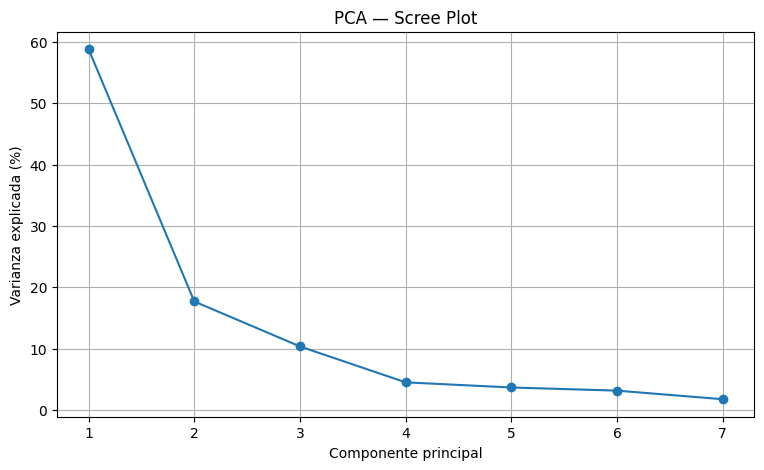

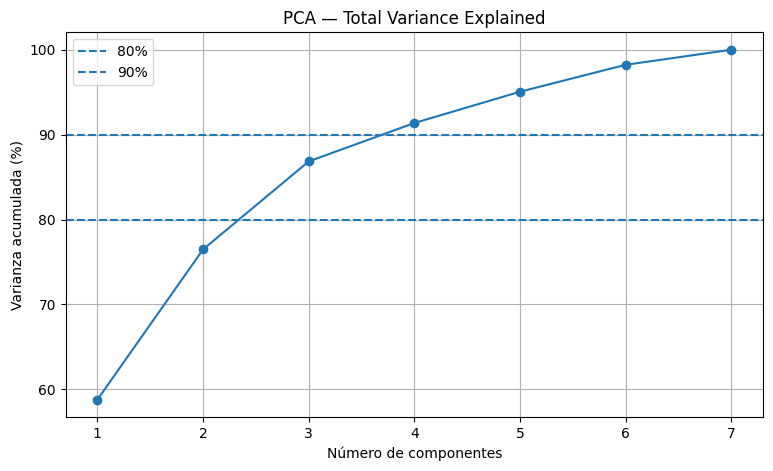

In [4]:

# Scree Plot + varianza acumulada
fig, ax = plt.subplots()
x = np.arange(1, len(pca.explained_variance_ratio_) + 1)
ax.plot(x, pca.explained_variance_ratio_ * 100, marker='o')
ax.set_xlabel('Componente principal')
ax.set_ylabel('Varianza explicada (%)')
ax.set_title('PCA — Scree Plot')
plt.show()

fig, ax = plt.subplots()
ax.plot(x, np.cumsum(pca.explained_variance_ratio_) * 100, marker='o')
ax.axhline(80, linestyle='--', label='80%')
ax.axhline(90, linestyle='--', label='90%')
ax.set_xlabel('Número de componentes')
ax.set_ylabel('Varianza acumulada (%)')
ax.set_title('PCA — Total Variance Explained')
ax.legend()
plt.show()



### ¿Cómo leer estas gráficas?

- **Scree Plot:** permite ver qué componentes aportan mucha o poca varianza.
- **Varianza acumulada:** permite decidir cuántos componentes necesitamos para conservar una proporción razonable de la información.
- No existe un único porcentaje universalmente “correcto”: el número de componentes depende del objetivo del análisis.



# 2. K-Means — Clustering

### Dataset: `students-data.csv`

K-Means agrupa observaciones buscando minimizar la distancia de cada observación a su centroide.

### Métrica principal — Elbow Curve

La métrica que observamos es la **inercia** (Within-Cluster Sum of Squares):

$$
W_k = \sum_{c=1}^{k}\sum_{x_i \in C_c} ||x_i-\mu_c||^2
$$

Al aumentar
$$k$$, la inercia siempre disminuye. El objetivo de la **Elbow Rule** es identificar un punto a partir del cual añadir más clusters aporta mejoras cada vez menores.

### Número de clusters

El “número recomendado de clusters” no lo decide automáticamente el algoritmo. Es una decisión analítica basada en:

- Elbow Curve
- conocimiento del problema
- interpretabilidad
- estabilidad de la solución

> **Importante:** en clustering, un modelo puede producir clusters aunque la estructura real de los datos no sea especialmente fuerte.


In [5]:

STUDENTS_URL = 'https://github.com/manoelgadi/PSDMA/raw/refs/heads/main/datasets/students-data.csv'
students = cargar_desde_url(STUDENTS_URL, 'csv')
students.head()


,Exam_Grade,Attendance,Rank
0,50,54,P
1,50,55,P
2,51,55,P
3,51,47,P
4,52,58,P


In [6]:

X_students = columnas_numericas_utiles(students)
X_students = X_students.fillna(X_students.median(numeric_only=True))
X_students_scaled = StandardScaler().fit_transform(X_students)

ks = range(2, 11)
inertias = []
for k in ks:
    model = KMeans(n_clusters=k, random_state=42, n_init=20)
    model.fit(X_students_scaled)
    inertias.append(model.inertia_)

elbow = pd.DataFrame({'k': list(ks), 'Inercia': inertias})
elbow


,k,Inercia
0,2,27.889416
1,3,13.265062
2,4,9.334173
3,5,5.911144
4,6,4.692438
5,7,3.925096
6,8,3.145668
7,9,2.668425
8,10,2.297201


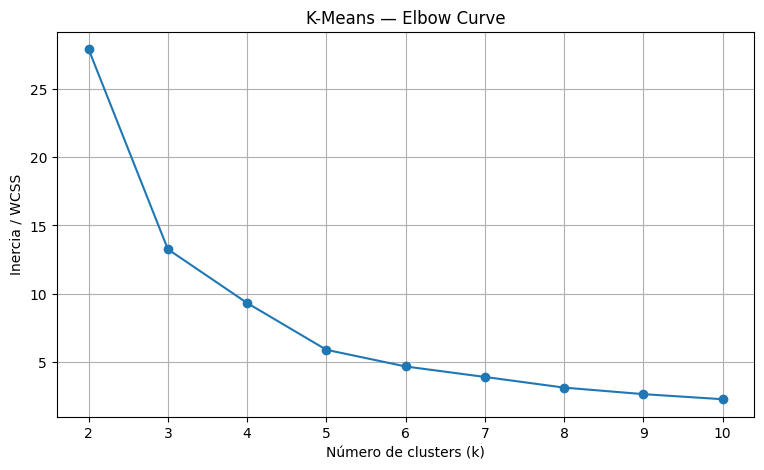

In [7]:

fig, ax = plt.subplots()
ax.plot(elbow['k'], elbow['Inercia'], marker='o')
ax.set_xlabel('Número de clusters (k)')
ax.set_ylabel('Inercia / WCSS')
ax.set_title('K-Means — Elbow Curve')
plt.show()



### Actividad rápida de interpretación

Mira la Elbow Curve antes de ejecutar cualquier modelo definitivo.

**Pregunta:** ¿en qué punto crees que añadir un nuevo cluster empieza a aportar poco beneficio?

No busques únicamente un número. Explica **por qué** ese valor parece razonable.


In [8]:
# Elegimos el numero de clusters a partir de la Elbow Curve
# Cambia este valor si tu interpretacion del codo sugiere otro k
k_elegido = 3

kmeans_final = KMeans(n_clusters=k_elegido, random_state=42, n_init=20)
clusters = kmeans_final.fit_predict(X_students_scaled)

# Volvemos al dataset original y anadimos el cluster asignado a cada alumno
students_clusters = students.copy()
students_clusters['Cluster'] = clusters

print(f"Dataset students con los clusters asignados (k = {k_elegido}):")
display(students_clusters)

print("Numero de observaciones por cluster:")
display(students_clusters['Cluster'].value_counts().sort_index().rename('Numero de alumnos').to_frame())


Dataset students con los clusters asignados (k = 3):


,Exam_Grade,Attendance,Rank,Cluster
0,50,54,P,2
1,50,55,P,2
2,51,55,P,2
3,51,47,P,2
4,52,58,P,2
5,55,53,P,2
6,55,59,P,2
7,57,60,P,2
8,57,56,P,2
9,57,55,P,2


Numero de observaciones por cluster:


,Numero de alumnos
Cluster,
0,17
1,14
2,18



# 3. Linear Regression — Métricas

### Dataset: `01_housing.csv`

En regresión lineal queremos explicar/predicir una variable continua
$$y$$.

Las tres métricas centrales de esta sesión serán:

### SSE — Sum of Squared Errors

$$
SSE = \sum_{i=1}^{n}(y_i-\hat{y}_i)^2
$$

Mide el **error total al cuadrado**. Cuanto menor, mejor, pero depende del tamaño y de la escala de
$$y$$.

### MSE — Mean Squared Error

$$
MSE = fracrac{1}{n}\sum_{i=1}^{n}(y_i-\hat{y}_i)^2 = fracrac{SSE}{n}
$$

Es el error cuadrático medio. Tiene las unidades al cuadrado de la variable objetivo.

### R² — Coeficiente de determinación

$$
R^2=1-fracrac{SSE}{SST}
$$

con:

$$
SST=\sum_{i=1}^{n}(y_i-barar{y})^2
$$

R² compara el modelo con una referencia muy sencilla: **predecir siempre la media**.

-
$$R^2=1$$: ajuste perfecto.
-
$$R^2=0$$: el modelo no mejora a la predicción constante basada en la media.
- Puede ser negativo fuera de ciertos contextos de ajuste/evaluación.


In [9]:

HOUSING_URL = 'https://github.com/manoelgadi/PSDMA/raw/refs/heads/main/datasets/01_housing.csv'
housing = cargar_desde_url(HOUSING_URL, 'csv')
housing.head()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [10]:

# Elegimos automáticamente una variable objetivo continua.
# Si existe 'medv', se utiliza; si no, se toma la última columna numérica.
numeric_cols = housing.select_dtypes(include=np.number).columns.tolist()
if 'medv' in housing.columns:
    TARGET = 'medv'
elif 'MEDV' in housing.columns:
    TARGET = 'MEDV'
else:
    TARGET = numeric_cols[-1]

features = [c for c in numeric_cols if c != TARGET]
X = housing[features].copy().fillna(housing[features].median(numeric_only=True))
y = housing[TARGET].copy().fillna(housing[TARGET].median())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)
y_pred = model_lr.predict(X_test)

sse = float(np.sum((y_test - y_pred) ** 2))
mse = float(mean_squared_error(y_test, y_pred))
r2 = float(r2_score(y_test, y_pred))

metricas_lr = pd.DataFrame({
    'Métrica': ['SSE', 'MSE', 'R²'],
    'Valor': [sse, mse, r2]
})
metricas_lr


,Métrica,Valor
0,SSE,2.548515e+13
1,MSE,4.938982e+09
2,R²,6.267447e-01


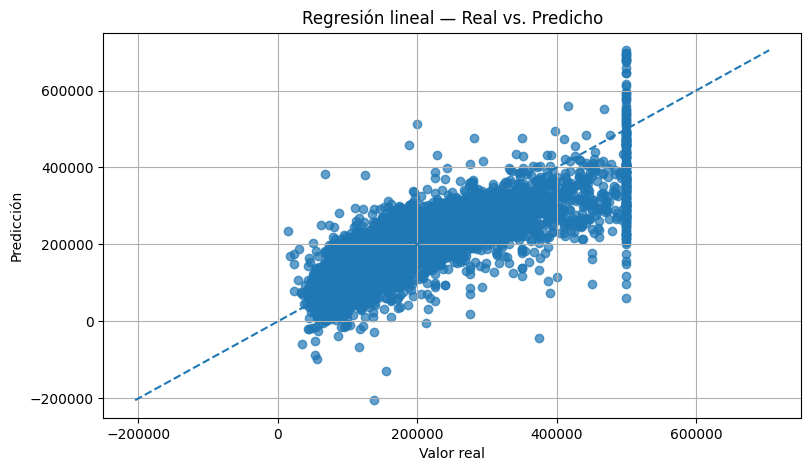

In [11]:

fig, ax = plt.subplots()
ax.scatter(y_test, y_pred, alpha=0.7)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
ax.plot(lims, lims, linestyle='--')
ax.set_xlabel('Valor real')
ax.set_ylabel('Predicción')
ax.set_title('Regresión lineal — Real vs. Predicho')
plt.show()



### Mensaje clave

**SSE y MSE hablan del tamaño del error. R² habla del porcentaje del error explicado por el modelo en relación con el modelo de referencia basado en la media.**

No confundas R² con “porcentaje de predicciones correctas”: eso pertenece a otro tipo de problema, como la clasificación.



# 4. Logistic Regression — Métricas de clasificación

### Dataset: Titanic

En clasificación binaria, la variable objetivo solo tiene dos resultados, por ejemplo:

```text
0 = no sobrevive
1 = sobrevive
```

La regresión logística estima una **probabilidad**, que posteriormente se transforma en una clase usando un umbral.

Aquí nos interesa especialmente la **matriz de confusión** y las métricas derivadas de ella.

## Matriz de confusión

| | Real = 0 | Real = 1 |
|---|---:|---:|
| **Predicción = 0** | TN | FN |
| **Predicción = 1** | FP | TP |

- **TP:** verdaderos positivos
- **TN:** verdaderos negativos
- **FP:** falsos positivos
- **FN:** falsos negativos


## Métricas derivadas de la matriz de confusión

### Accuracy

$$
Accuracy=\frac{TP+TN}{TP+TN+FP+FN}
$$

Proporción de observaciones clasificadas correctamente. Depende del **punto de corte** elegido para convertir la probabilidad en una clase.

### Precision

$$
Precision=\frac{TP}{TP+FP}
$$

De todos los casos que el modelo predijo como positivos, ¿cuántos eran realmente positivos? Es especialmente relevante cuando el **falso positivo** tiene un coste importante.

### Recall / Sensitivity

$$
Recall=\frac{TP}{TP+FN}
$$

De todos los positivos reales, ¿cuántos conseguimos detectar? Es especialmente relevante cuando el **falso negativo** tiene un coste importante.

### F1-score

$$
F1=2\cdot\frac{Precision\cdot Recall}{Precision+Recall}
$$

Es la media armónica entre Precision y Recall. Al ser una media armónica, el resultado se aproxima más al **menor** de los dos valores que al mayor. Por eso ayuda a evitar que una Precision muy alta compense artificialmente un Recall muy bajo, o al contrario.

### Una idea fundamental: el punto de corte

Accuracy, Precision, Recall y F1-score necesitan transformar la probabilidad estimada por el modelo en una decisión de clase mediante un **umbral**. Habitualmente se utiliza 50%, pero el punto de corte puede definirse de otra manera según el problema y el coste de los errores.


In [12]:

TITANIC_URL = 'https://github.com/manoelgadi/PSDMA/raw/refs/heads/main/datasets/titanic_data.csv'
titanic = cargar_desde_url(TITANIC_URL, 'csv')
titanic.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [13]:

# Modelo didáctico: utilizamos variables sencillas y explicables.
cols = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare']
work = titanic[cols + ['Survived']].copy()
work['Age'] = work['Age'].fillna(work['Age'].median())
work['Fare'] = work['Fare'].fillna(work['Fare'].median())
work['Sex'] = work['Sex'].map({'male': 0, 'female': 1})
work = work.dropna()

X = work[cols]
y = work['Survived'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

logit = LogisticRegression(max_iter=1000)
logit.fit(X_train, y_train)

p_test = logit.predict_proba(X_test)[:, 1]
y_pred = (p_test >= 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred)
print('Matriz de confusión:')
print(cm)

print('\nClassification report:')
print(classification_report(y_test, y_pred, digits=3))


Matriz de confusión:
[[112  25]
 [ 24  62]]

Classification report:
              precision    recall  f1-score   support

           0      0.824     0.818     0.821       137
           1      0.713     0.721     0.717        86

    accuracy                          0.780       223
   macro avg      0.768     0.769     0.769       223
weighted avg      0.781     0.780     0.781       223



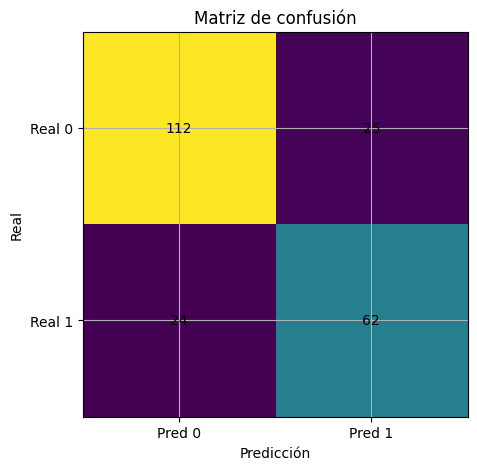

,Métrica,Valor
0,Accuracy,0.780269
1,Precision,0.712644
2,Recall,0.720930
3,F1-score,0.716763


In [14]:

# Matriz de confusión visual
fig, ax = plt.subplots()
im = ax.imshow(cm)
ax.set_xticks([0, 1], labels=['Pred 0', 'Pred 1'])
ax.set_yticks([0, 1], labels=['Real 0', 'Real 1'])
ax.set_title('Matriz de confusión')
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha='center', va='center')
ax.set_xlabel('Predicción')
ax.set_ylabel('Real')
plt.show()

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

metricas_clas = pd.DataFrame({
    'Métrica': ['Accuracy', 'Precision', 'Recall', 'F1-score'],
    'Valor': [accuracy, precision, recall, f1]
})
metricas_clas


## AUC — Area Under the ROC Curve

La **ROC Curve** representa:

$$
TPR = Recall = \frac{TP}{TP+FN}
$$

frente a:

$$
FPR=\frac{FP}{FP+TN}
$$

para diferentes umbrales.

El **AUC** es el área bajo esta curva:

- AUC = 1 → separación perfecta.
- AUC = 0.5 → comportamiento equivalente a azar, en términos de ranking.
- Cuanto mayor sea el AUC, mejor separa el modelo los positivos de los negativos **de manera global**, independientemente de un único umbral.

### GINI

En scoring/risk modelling es frecuente utilizar:

$$
Gini = 2\cdot AUC - 1
$$

Por tanto:

$$
AUC=0.75 \Rightarrow Gini=0.50
$$


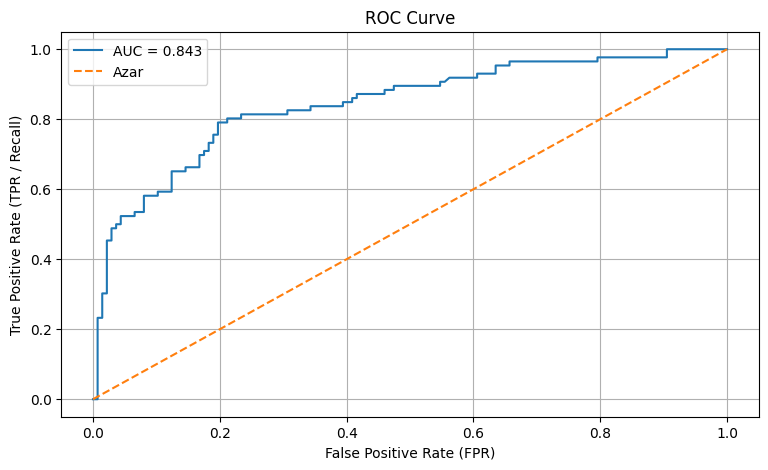

AUC  = 0.8431
GINI = 0.6862


In [15]:

auc = roc_auc_score(y_test, p_test)
gini = 2 * auc - 1

fpr, tpr, thresholds = roc_curve(y_test, p_test)

fig, ax = plt.subplots()
ax.plot(fpr, tpr, label=f'AUC = {auc:.3f}')
ax.plot([0, 1], [0, 1], linestyle='--', label='Azar')
ax.set_xlabel('False Positive Rate (FPR)')
ax.set_ylabel('True Positive Rate (TPR / Recall)')
ax.set_title('ROC Curve')
ax.legend()
plt.show()

print(f'AUC  = {auc:.4f}')
print(f'GINI = {gini:.4f}')


## KS Statistic — Kolmogorov-Smirnov

Para un problema de scoring, podemos comparar la distribución acumulada de las probabilidades asignadas a positivos y negativos.

Una forma práctica de expresarlo es:

$$
KS = \max_{t}\left|TPR(t)-FPR(t)\right|
$$

El **KS máximo** indica el punto en el que la separación entre ambas distribuciones acumuladas es mayor.

- KS cercano a 0 → poca capacidad de separación.
- KS mayor → mayor separación entre positivos y negativos.

El umbral asociado al KS máximo puede ser útil para estudiar puntos de corte, aunque la elección final del umbral depende del problema de negocio.


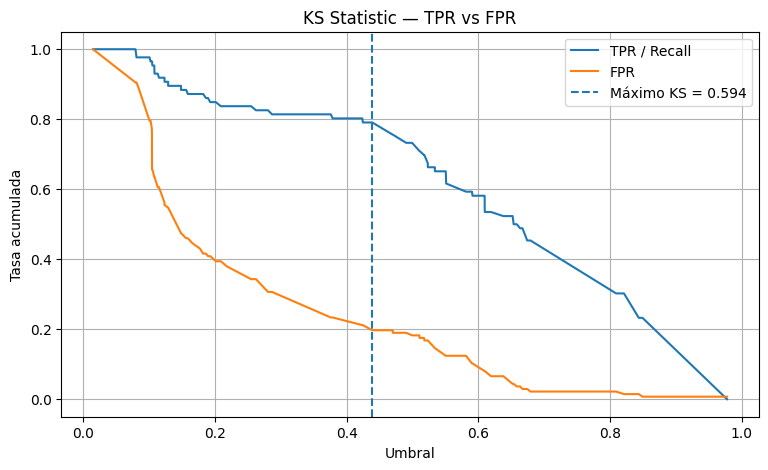

KS máximo = 0.5936
Umbral asociado ≈ 0.4388


In [16]:

ks_values = np.abs(tpr - fpr)
idx = np.argmax(ks_values)
ks = ks_values[idx]
ks_threshold = thresholds[idx]

fig, ax = plt.subplots()
ax.plot(thresholds, tpr, label='TPR / Recall')
ax.plot(thresholds, fpr, label='FPR')
ax.axvline(ks_threshold, linestyle='--', label=f'Máximo KS = {ks:.3f}')
ax.set_xlabel('Umbral')
ax.set_ylabel('Tasa acumulada')
ax.set_title('KS Statistic — TPR vs FPR')
ax.legend()
plt.show()

print(f'KS máximo = {ks:.4f}')
print(f'Umbral asociado ≈ {ks_threshold:.4f}')


## Adjusted R-Square y regresión logística

En **regresión lineal** sí existe un R² ajustado estándar:

$$
\bar{R}^2 = 1 - (1-R^2)\frac{n-1}{n-p-1}
$$

donde `n` es el número de observaciones y `p` el número de predictores.

En **regresión logística no existe un “Adjusted R-Square” único y universal** equivalente al R² lineal. En su lugar se utilizan diferentes **pseudo-R²**.

Para mantener el concepto en clase, podemos mostrar el **McFadden pseudo-R²** y una versión ajustada para penalizar el número de parámetros:

$$
R^2_{McFadden}=1-\frac{LL_{modelo}}{LL_{null}}
$$

$$
R^2_{McFadden,aj}=1-\frac{LL_{modelo}-k}{LL_{null}}
$$

donde `LL` es la log-verosimilitud y `k` es el número de parámetros estimados.

> **Importante:** se trata de un **pseudo-R²**, no del R² de una regresión lineal. No debe interpretarse como “porcentaje de varianza explicada”.


In [17]:

# Cálculo didáctico de McFadden y McFadden ajustado

def log_likelihood_binary(y_true, p):
    eps = 1e-15
    p = np.clip(p, eps, 1 - eps)
    y_true = np.asarray(y_true)
    return float(np.sum(y_true * np.log(p) + (1 - y_true) * np.log(1 - p)))

ll_model = log_likelihood_binary(y_test, p_test)
p_null = np.repeat(y_train.mean(), len(y_test))
ll_null = log_likelihood_binary(y_test, p_null)
k = X_train.shape[1] + 1  # predictores + intercepto

mcfadden_r2 = 1 - (ll_model / ll_null)
mcfadden_adj = 1 - ((ll_model - k) / ll_null)

print(f'McFadden pseudo-R²          = {mcfadden_r2:.4f}')
print(f'McFadden pseudo-R² ajustado = {mcfadden_adj:.4f}')


McFadden pseudo-R²          = 0.2950
McFadden pseudo-R² ajustado = 0.2479



# 🧠 Resumen de las métricas

| Modelo | Métrica | Pregunta que responde |
|---|---|---|
| **PCA** | Scree Plot | ¿Qué componentes aportan más varianza? |
| **PCA** | Total Variance Explained | ¿Cuánta información acumulada conservamos? |
| **K-Means** | Elbow / Inercia | ¿Cuánto mejora la solución al aumentar k? |
| **K-Means** | Número de clusters | ¿Qué k resulta razonable para el problema? |
| **Linear Regression** | SSE | ¿Cuál es el error cuadrático total? |
| **Linear Regression** | MSE | ¿Cuál es el error cuadrático medio? |
| **Linear Regression** | R² | ¿Cuánto mejora frente a predecir la media? |
| **Logistic Regression** | Accuracy | ¿Qué proporción clasificamos correctamente? |
| **Logistic Regression** | Precision | ¿Qué proporción de positivos predichos son correctos? |
| **Logistic Regression** | Recall | ¿Qué proporción de positivos reales detectamos? |
| **Logistic Regression** | F1 | ¿Cómo equilibramos Precision y Recall? |
| **Logistic Regression** | AUC | ¿Qué capacidad global tiene el modelo para ordenar positivos y negativos? |
| **Logistic Regression** | GINI | ¿Cuánta capacidad de discriminación refleja el AUC? |
| **Logistic Regression** | KS | ¿Cuál es la máxima separación entre TPR y FPR? |
| **Logistic Regression** | Pseudo-R² | ¿Mejora el modelo respecto al modelo nulo, según una medida de verosimilitud? |

> **Idea final:** ninguna métrica debería analizarse de forma aislada. La elección de la métrica debe estar conectada con el objetivo y con el coste de los errores.



## Fuentes de datos

- Crime: https://github.com/manoelgadi/PSDMA/raw/refs/heads/main/datasets/crime.csv
- Students: https://github.com/manoelgadi/PSDMA/raw/refs/heads/main/datasets/students-data.csv
- Housing: https://github.com/manoelgadi/PSDMA/raw/refs/heads/main/datasets/01_housing.csv
- Titanic: https://github.com/manoelgadi/PSDMA/raw/refs/heads/main/datasets/titanic_data.csv


# 🧠 Conclusión: métricas de clasificación

Las métricas de clasificación no responden todas a la misma pregunta. Algunas dependen de un **punto de corte** para transformar una probabilidad en una decisión; otras permiten evaluar el poder de discriminación del modelo sin fijar todavía ese punto de corte.

| Métrica | ¿Qué mide? | Punto de corte | Interpretación práctica |
|---|---|---|---|
| **Accuracy** | Proporción de observaciones clasificadas correctamente. $$Accuracy=\frac{TP+TN}{TP+TN+FP+FN}$$ | **Sí** | Es adecuada cuando se trabaja con un punto de corte definido (habitualmente 50%), las clases están razonablemente balanceadas y los errores tienen un peso similar. Si estas condiciones no se cumplen, puede resultar engañosa. |
| **Precision** | De los positivos predichos, qué proporción son realmente positivos. $$Precision=\frac{TP}{TP+FP}$$ | **Sí** | Útil cuando el **Error Tipo I / falso positivo** es especialmente importante o costoso. |
| **Recall** | De los positivos reales, qué proporción conseguimos detectar. $$Recall=\frac{TP}{TP+FN}$$ | **Sí** | Útil cuando el **Error Tipo II / falso negativo** es especialmente importante o costoso. |
| **F1-score** | Combina Precision y Recall mediante la media armónica. $$F1=2\cdot\frac{Precision\cdot Recall}{Precision+Recall}$$ | **Sí** | Intenta dar importancia a que ninguna de las dos métricas sea muy baja. Al ser una media armónica, se acerca más al menor valor entre Precision y Recall. |
| **AUC — Area Under the ROC Curve** | Resume la capacidad del modelo para ordenar los positivos por encima de los negativos considerando los diferentes puntos de corte. | **No** | Permite retrasar la decisión sobre el punto de corte. Resulta útil cuando el umbral operativo se definirá posteriormente según la gestión del negocio. |
| **GINI** | Se deriva directamente del AUC. $$GINI=2\cdot AUC-1$$ | **No** | Resume la discriminación del modelo utilizando todos los puntos de corte posibles. Su escala habitual va de 0 a 1 en el contexto de esta clase. |
| **KS — Kolmogorov-Smirnov** | Máxima diferencia entre TPR y FPR a través de los puntos de corte. $$KS=\max_t\left|TPR(t)-FPR(t)\right|$$ | **No para calcularla; sí identifica un umbral** | Indica el punto de corte en el que se obtiene la **máxima separación** entre las dos poblaciones. Puede utilizarse para localizar el mejor punto de corte observado durante el desarrollo. |

### Idea final

**Accuracy, Precision, Recall y F1-score** necesitan un punto de corte fijo: normalmente 50%, aunque en la práctica puede definirse otro. Por tanto, estas métricas describen el comportamiento del modelo **para un umbral concreto**.

Cuando los errores no tienen el mismo peso, la métrica de interés puede cambiar: **Precision** se centra más en evitar falsos positivos, mientras que **Recall** se centra más en evitar falsos negativos. **F1-score** intenta equilibrar ambas dimensiones y penaliza que una de ellas sea mucho menor que la otra.

Por otra parte, **AUC y GINI** tienen la ventaja de evaluar el modelo utilizando los diferentes puntos de corte posibles, sin tener que decidir todavía cuál será el umbral operativo. Como intuición, pueden verse como una medida global del comportamiento del modelo a través de todos los umbrales; **no son un promedio simple de los puntos de corte**.

El **KS** sigue una lógica diferente: busca el **máximo** nivel de separación que puede conseguirse entre las distribuciones de las dos clases y permite localizar el umbral asociado a ese máximo.

> **No existe una métrica universalmente mejor: la métrica debe elegirse en función del equilibrio de las clases, del coste relativo de los errores y de cuándo se quiere tomar la decisión sobre el punto de corte.**
